# Milestone 1 — Zrozumienie zbioru danych

Ten notebook analizuje log zdarzeń z datasetu Nine Rooks (2023-04-28): produkcja 9 figur szachowych w środowisku CPEE.

Dataset opisuje trzy główne źródła danych:
- EMCO MT45 Lathe — obróbka tokarska aluminium,
- ABB IRB-2600 — robotyczne przenoszenie i manipulacja detalem,
- Keyence LS-7000 — pomiar końcowy / kontrola jakości blisko produkcji.

W praktyce oznacza to, że log pokazuje pełny przebieg procesu dla 9 wyprodukowanych części: od wytworzenia, przez obsługę robota, aż po pomiar jakości.

Zawartość:
- kontekst procesu i jakie przypadki (cases) występują w logu,
- dostępne atrybuty: `case_id`, `activity`, `timestamp`, `resource`, `lifecycle`,
- jakość danych: braki, duplikaty, błędne znaczniki czasu i niespójne typy,
- podstawowe statystyki oraz proste wizualizacje do interpretacji logu.


## 1. Wczytanie danych

In [18]:
import os
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from yaml import CSafeLoader as SafeLoader
except ImportError:
    from yaml import SafeLoader


data_folder = 'data'
file_list = [f for f in os.listdir(data_folder) if os.path.isfile(os.path.join(data_folder, f))]

events = []
invalid_files = 0

for file_name in file_list:
    file_path = os.path.join(data_folder, file_name)
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for doc in yaml.load_all(file, Loader=SafeLoader):
                if not doc or 'event' not in doc:
                    continue

                event_data = doc['event']
                # W CPEE stabilniejszy identyfikator instancji procesu to cpee:instance (UUID)
                case_id = event_data.get('cpee:instance') or event_data.get('concept:instance')
                activity = event_data.get('concept:name') or event_data.get('cpee:activity') or event_data.get('cpee:name')
                timestamp = event_data.get('time:timestamp')
                lifecycle = event_data.get('lifecycle:transition') or event_data.get('cpee:lifecycle:transition')
                resource = None
                activity_str = str(activity) if activity else ''

                if any(token in activity_str for token in ['IRB2600', 'Robot']):
                    resource = 'IRB2600_Robot'
                elif any(token in activity_str for token in ['MT45', 'CNC']):
                    resource = 'MT45_CNC'

                if not resource and 'data' in event_data and isinstance(event_data['data'], list):
                    for item in event_data['data']:
                        val = str(item.get('value', ''))
                        if 'PF_IRB2600' in val or 'IRB2600' in val:
                            resource = 'IRB2600_Robot'
                            break
                        if 'MT45' in val or 'CNC' in val:
                            resource = 'MT45_CNC'
                            break

                events.append(
                    {
                        'source_file': file_name,
                        'case_id': case_id,
                        'activity': activity,
                        'timestamp': timestamp,
                        'lifecycle': lifecycle,
                        'resource': resource,
                    }
                )
    except Exception:
        invalid_files += 1

df = pd.DataFrame(events)

null_counts = df.isnull().sum()
duplicate_count = df.duplicated(subset=['case_id', 'activity', 'timestamp', 'lifecycle']).sum()

df_clean = df.dropna(subset=['case_id', 'activity']).copy()
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'], errors='coerce')
df_clean = df_clean.sort_values(['case_id', 'timestamp']).reset_index(drop=True)


## Jak czytać log


W tym zbiorze danych pojedynczy plik opisuje jeden przypadek procesu. Najważniejsze pola, które chcemy odnaleźć, to:



- `case_id` — identyfikator przypadku procesu,

- `activity` — nazwa aktywności / kroku procesu,

- `timestamp` — czas wykonania zdarzenia,

- `resource` — maszyna, urządzenie lub zasób, jeśli da się go zrekonstruować,

- `lifecycle` — faza zdarzenia, np. `complete` albo zdarzenia pomocnicze.



Jeśli któreś pole jest brakujące, to jest to ważna informacja o jakości logu albo o tym, że dane są zapisane w bardziej złożonej strukturze niż klasyczny log eventowy.

## Dlaczego procesów jest dużo?


Krótko: w tych danych **„process / case” może oznaczać różne poziomy**.



- Poziom techniczny: wiele instancji workflow (sub-procesy, wywołania usług, eventy systemowe).

- Poziom biznesowy: produkcja pojedynczej figury (to Ciebie interesuje najbardziej).



Dlatego liczba „cases” jest duża, jeśli liczymy wszystkie instancje techniczne.

To normalne dla CPEE/XES SensorStream.



Różna liczba zdarzeń na case też jest normalna, bo:

- część instancji to krótkie kroki techniczne,

- część to dłuższe fragmenty procesu (tokarka, robot, pomiar),

- dochodzą eventy pomocnicze (`external`, `unknown`, zmiany stanu).



Wniosek: do analizy „jednej figury” trzeba patrzeć na najwyższy poziom procesu, a nie na wszystkie techniczne instancje naraz.

In [19]:
# Analiza poziomów procesu na podstawie nagłówków trace w plikach .xes.yaml
trace_rows = []

for file_name in file_list:
    file_path = os.path.join(data_folder, file_name)
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            docs = yaml.load_all(f, Loader=SafeLoader)
            first_doc = next(docs, None)

        if isinstance(first_doc, dict) and 'log' in first_doc:
            trace = first_doc['log'].get('trace', {})
            trace_rows.append(
                {
                    'source_file': file_name,
                    'trace_name': trace.get('cpee:name'),
                    'trace_concept_name': trace.get('concept:name'),
                    'trace_instance': trace.get('cpee:instance'),
                }
            )
    except Exception:
        pass

df_traces = pd.DataFrame(trace_rows)

print('Liczba plików/instancji trace:', len(df_traces))
print('\nNajczęstsze nazwy trace (top 12):')
print(df_traces['trace_name'].value_counts().head(12).to_string())

single_part_traces = df_traces[df_traces['trace_name'].astype(str).str.contains('Turm Single', case=False, na=False)]
print('\nInstancje typu "Turm Single" (przybliżenie procesu jednej figury):', len(single_part_traces))

print('\nLiczba case_id w eventach (poziom techniczny):', df_clean['case_id'].nunique())
print('To zwykle więcej niż liczba figur, bo zawiera sub-procesy i eventy pomocnicze.')

Liczba plików/instancji trace: 234

Najczęstsze nazwy trace (top 12):
trace_name
X MT45 Control Setter            54
X IRB2600 Execution              13
Machining V2                     11
X MT45 Control Getter             9
IRB2600 Portal to Door            9
MT45 Check Operational Safety     9
IRB2600 Door to Portal            9
X Generate NC                     9
Turm Turn Production              9
Turm MT45 Take Out                9
IRB2600 IRB2600 GS to Door        9
Turm IRB2600 Extract              9

Instancje typu "Turm Single" (przybliżenie procesu jednej figury): 9

Liczba case_id w eventach (poziom techniczny): 234
To zwykle więcej niż liczba figur, bo zawiera sub-procesy i eventy pomocnicze.


### Interpretacja powyższych liczb (ważne)


- `Liczba plików/instancji trace = 234` oznacza, że w zbiorze zapisano **234 instancje workflow na poziomie technicznym**.

- `Instancje typu Turm Single = 9` oznacza, że tylko **9 instancji odpowiada poziomowi jednej figury**.

- `Liczba case_id w eventach = 234` jest zgodna z poziomem technicznym, bo `case_id` identyfikuje instancje CPEE (w tym sub-procesy).



Czyli: **nie każdy case = jedna figura**.

W tym datasetcie jedna figura jest realizowana przez wiele kroków i podprocesów (np. `Control Setter`, `Generate NC`, `IRB2600 Execution`, pomiary), dlatego liczba zdarzeń między case’ami technicznymi jest rozbieżna.



Do analizy biznesowej (jakość i porównanie 9 figur) najlepiej używać poziomu `Turm Single` i traktować pozostałe trace jako szczegółowe składowe procesu.

## Jakie wnioski można z tego wyciągnąć?


1. **Porównanie cases** — sprawdzić, czy wszystkie 9 części przechodzą podobną ścieżkę procesu, czy są różnice w kolejności, liczbie zdarzeń albo czasie trwania.

2. **Dominujące etapy procesu** — zobaczyć, które aktywności pojawiają się najczęściej i które etapy pochłaniają najwięcej czasu.

3. **Udział zasobów** — porównać, ile zdarzeń pochodzi z maszyny MT45, ile z robota IRB-2600, a ile z pomiaru Keyence.

4. **Jakość danych** — wykryć braki w `timestamp`, duplikaty, niezgodne typy oraz zdarzenia techniczne (`start`, `complete`, `external`, `unknown`).

5. **Timeline procesu** — sprawdzić, kiedy w czasie pojawiają się zdarzenia i czy proces jest równomierny, czy występują skupiska aktywności.

6. **Potencjalne anomalie jakościowe** — jeśli jakaś część ma nietypowo dużo zdarzeń, brakuje jej pomiaru albo ma inny przebieg, to może wskazywać na problem produkcyjny albo procesowy.


In [2]:
print('Raw dataframe preview:')
print(df.head(10).to_string(index=False))

attribute_summary = pd.DataFrame(
    {
        'missing_count': df.isna().sum(),
        'missing_pct': (df.isna().mean() * 100).round(2),
        'dtype': df.dtypes.astype(str),
    }
)
print('\nAttribute summary:')
print(attribute_summary.to_string())

print('\nUnique values in lifecycle:')
print(df['lifecycle'].value_counts(dropna=False).to_string())

Raw dataframe preview:
 case_id activity                     timestamp lifecycle resource
    5744 external 2023-04-28T17:29:51.342+02:00   unknown      NaN
    5744 external 2023-04-28T17:29:51.395+02:00   unknown      NaN
    5744 external 2023-04-28T17:29:51.421+02:00   unknown      NaN
    5744 external 2023-04-28T17:29:51.407+02:00   unknown MT45_CNC
    5744 external 2023-04-28T17:29:51.405+02:00   unknown      NaN
    5744 Read Var 2023-04-28T17:29:54.025+02:00     start      NaN
    5744 external 2023-04-28T17:29:54.007+02:00   unknown      NaN
    5744 Read Var 2023-04-28T17:29:54.347+02:00   unknown      NaN
    5744 Read Var 2023-04-28T17:29:54.349+02:00  complete      NaN
    5744 Read Var 2023-04-28T17:29:54.349+02:00   unknown      NaN

Attribute summary:
           missing_count  missing_pct  dtype
case_id                0         0.00  int64
activity               0         0.00    str
timestamp           1097        10.39    str
lifecycle              0         0.00   

In [3]:
all_activities = df['activity'].dropna().unique()
potential_resources = [act for act in all_activities if 'IRB' in str(act) or 'MT' in str(act) or 'Machine' in str(act)]
print("Wykryte maszyny w nazwach zadań:")
print(set(potential_resources))



Wykryte maszyny w nazwach zadań:
{'Get Machine State Cancelled', 'Set Program MT45', 'IRB2600 Take to GS', 'IRB2600 Door to GS', 'IRB2600 Grip', 'MT45 Check Operational Safety', 'IRB2600 Extract', 'IRB2600 GS to Take', 'IRB2600 Door to Measure', 'MT45 Start', 'IRB2600 GS to Door', 'IRB2600 Unload to Tray Down', 'IRB2600 Door to Portal', 'Wait for MT45 Takeout', 'MT45 Take Out', 'IRB2600 Measure to Door', 'IRB2600 Portal to Door'}


In [4]:
print('### Data Overview')
print('Context: production-process event log from a CPEE-based system.')
print('The traces contain nested events connected with MT45 CNC and IRB2600 robot operations.')
print(f'Number of loaded files: {len(file_list)}')
print(f'Number of faulty files (not processed): {invalid_files}')
print(f'Total number of registered events (raw): {len(df)}')
print(f'Number of unique cases (Cases) in raw data: {df["case_id"].nunique()}')
print('-' * 30)

### Data Overview
Context: production-process event log from a CPEE-based system.
The traces contain nested events connected with MT45 CNC and IRB2600 robot operations.
Number of loaded files: 236
Number of faulty files (not processed): 1
Total number of registered events (raw): 10557
Number of unique cases (Cases) in raw data: 234
------------------------------


In [5]:
print("\n### Data Quality Check")

print("\na) Missing variables:")
print(df.isnull().sum())

duplicates = df.duplicated(subset=['case_id', 'activity', 'timestamp', 'lifecycle']).sum()
print(f"\nb) Number of potential duplicate events: {duplicates} ({(duplicates/len(df))*100:.2f}%)")

df_time_check = df.copy()
df_time_check['timestamp'] = pd.to_datetime(df_time_check['timestamp'], errors='coerce')
now = pd.Timestamp.now(tz='UTC')

future_events = df_time_check[df_time_check['timestamp'] > now]
print(f"c) Number of events in the future: {len(future_events)}")

print(f"\nd) Data types in columns:\n{df.dtypes}")

# how many times does each value appear?
print("\ne) Distribution of Lifecycle attribute:")
print(df['lifecycle'].value_counts(dropna=False))
print("-" * 30)


### Data Quality Check

a) Missing variables:
case_id         0
activity        0
timestamp    1097
lifecycle       0
resource     7852
dtype: int64

b) Number of potential duplicate events: 1168 (11.06%)
c) Number of events in the future: 0

d) Data types in columns:
case_id      int64
activity       str
timestamp      str
lifecycle      str
resource       str
dtype: object

e) Distribution of Lifecycle attribute:
lifecycle
unknown     7046
complete    1883
start       1628
Name: count, dtype: int64
------------------------------


In [6]:
print("\n### Statistics of the Event Log")

num_events = len(df_clean)
num_cases = df_clean['case_id'].nunique()
num_activities = df_clean['activity'].nunique()

print(f"Number of events: {num_events}")
print(f"Number of cases: {num_cases}")
print(f"Number of unique activities: {num_activities}")

# Statystyki zdarzeń na Case
events_per_case = df_clean.groupby('case_id').size()
print("\nStatistics of events per case:")
print(events_per_case.describe())

print("-" * 30)


### Statistics of the Event Log
Number of events: 10557
Number of cases: 234
Number of unique activities: 64

Statistics of events per case:
count    234.000000
mean      45.115385
std       33.902403
min       11.000000
25%       18.000000
50%       31.000000
75%       66.000000
max      175.000000
dtype: float64
------------------------------


/var/folders/h9/wcf716hj6t96gm_lz5tzq4jr0000gn/T/ipykernel_24706/2511542507.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


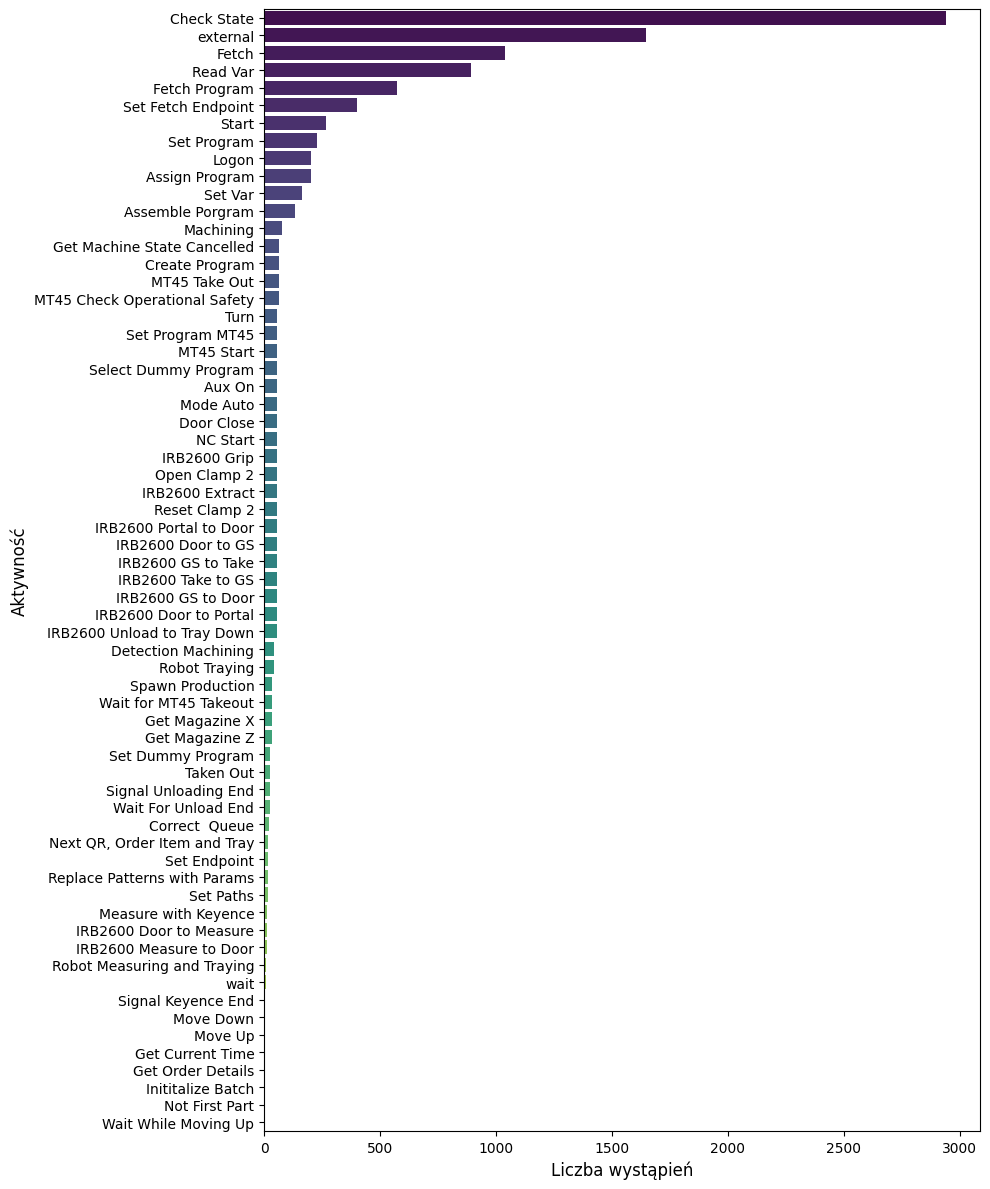

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

top_activities = df_clean['activity'].value_counts()
#
# For readability (OPTIONAL): Limit to top N activities
# top_n = 20
# top_activities = df_clean['activity'].value_counts().head(top_n)
# 

plt.figure(figsize=(10, 12)) 
sns.barplot(
    x=top_activities.values, 
    y=top_activities.index,
    palette="viridis"
)
plt.xlabel('Liczba wystąpień', fontsize=12)
plt.ylabel('Aktywność', fontsize=12)
plt.tight_layout()
plt.show()


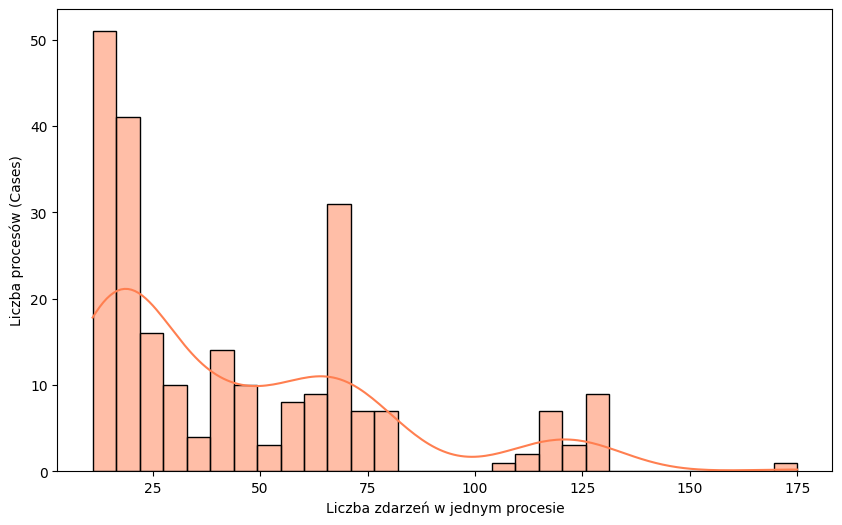

In [8]:

plt.figure(figsize=(10, 6))
events_per_case = df_clean.groupby('case_id').size()
sns.histplot(events_per_case, bins=30, kde=True, color="coral")
plt.xlabel('Liczba zdarzeń w jednym procesie')
plt.ylabel('Liczba procesów (Cases)')
plt.show()


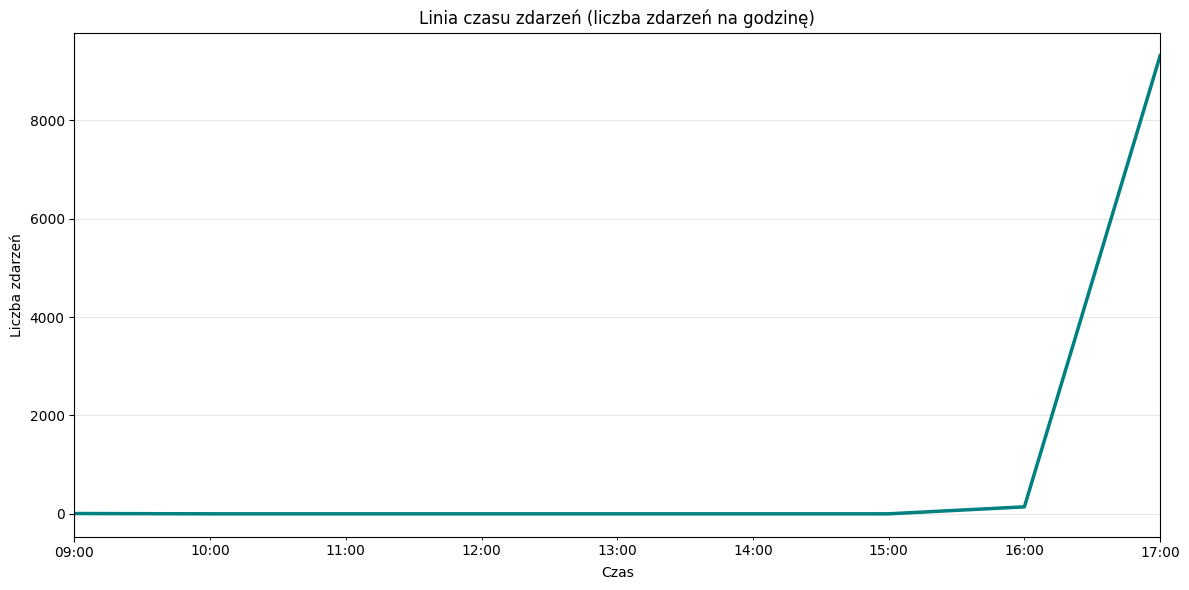

In [17]:
plt.figure(figsize=(12, 6))

valid_timestamps = df_clean.dropna(subset=['timestamp']).copy()

if valid_timestamps.empty:
    print('Brak poprawnych timestampów do wykresu timeline.')
else:
    timeline_data = valid_timestamps.set_index('timestamp').resample('h').size()
    timeline_data.plot(color='teal', linewidth=2.5)
    plt.title('Linia czasu zdarzeń (liczba zdarzeń na godzinę)')
    plt.xlabel('Czas')
    plt.ylabel('Liczba zdarzeń')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

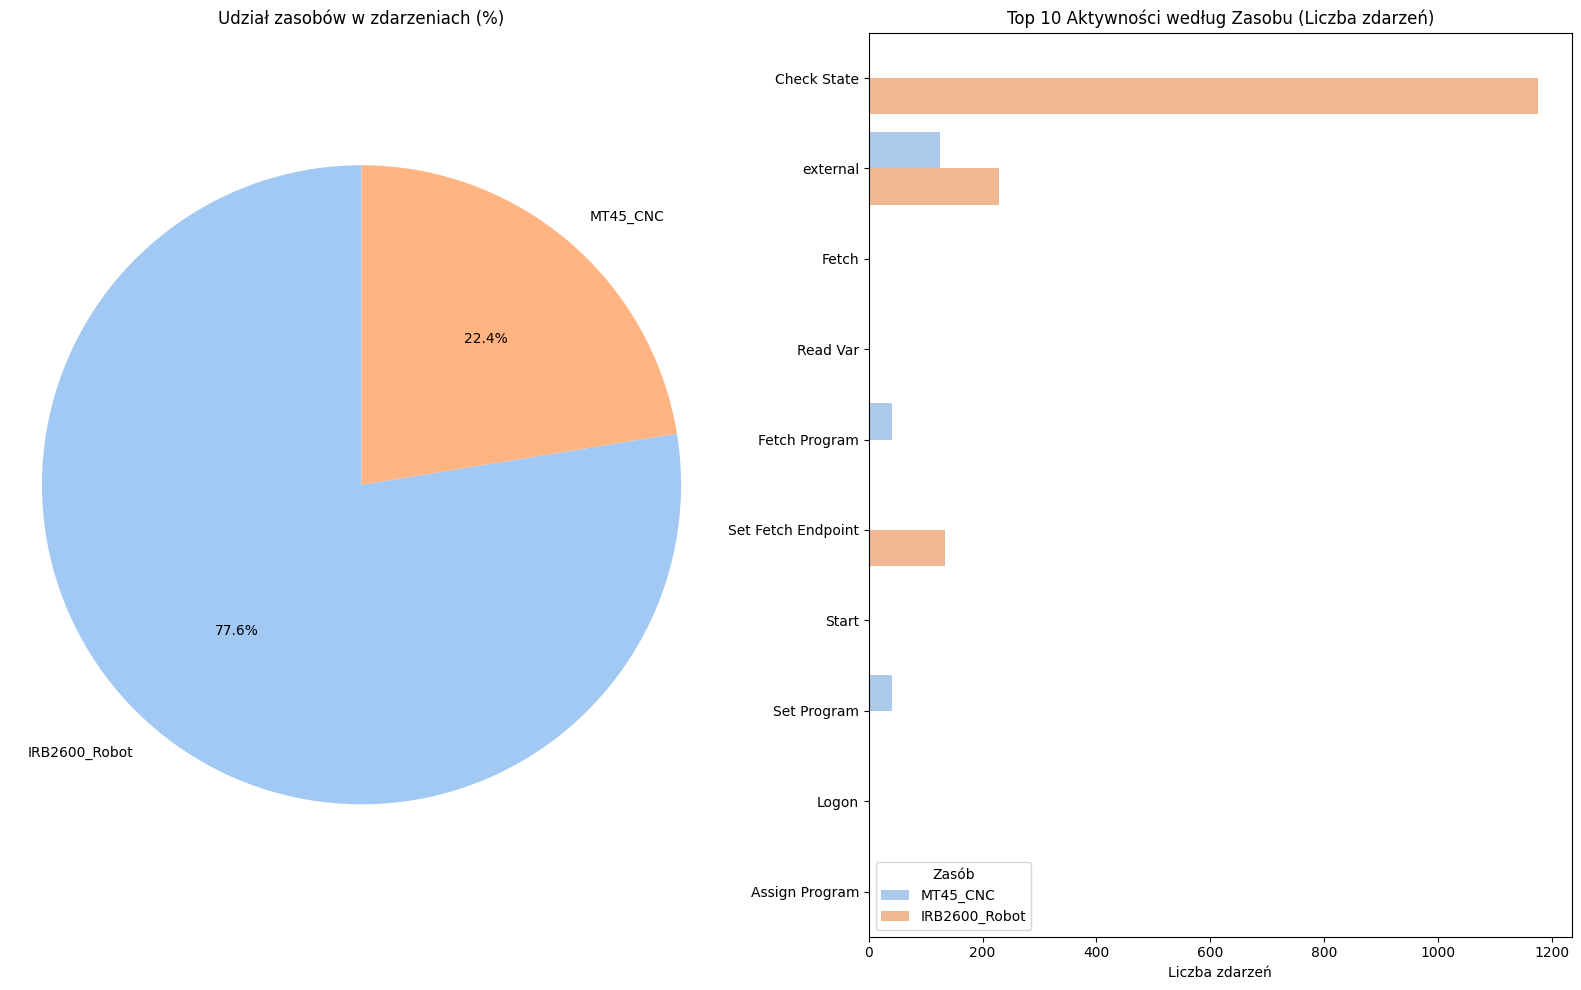

In [16]:
res_counts = df_clean['resource'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 10))

ax1.pie(res_counts, labels=res_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
ax1.axis('equal')
ax1.set_title('Udział zasobów w zdarzeniach (%)')

# Top 3 resources
top_resources = res_counts.head(3).index
df_res_act = df_clean[df_clean['resource'].isin(top_resources)]

# Top 10 activities overall
top_acts = df_clean['activity'].value_counts().head(10).index
df_res_act = df_res_act[df_res_act['activity'].isin(top_acts)]

sns.countplot(data=df_res_act, y='activity', hue='resource', palette='pastel', ax=ax2, order=top_acts)
ax2.set_title('Top 10 Aktywności według Zasobu (Liczba zdarzeń)')
ax2.set_xlabel('Liczba zdarzeń')
ax2.set_ylabel('')
ax2.legend(title='Zasób')

plt.tight_layout()
plt.show()

## Interpretacja wyników


Na podstawie dotychczasowych wykresów i tabel można odczytać kilka ważnych rzeczy:



- **Timeline** pokazuje rozkład zdarzeń w czasie i pomaga zobaczyć, czy proces przebiega równomiernie czy w krótkich seriach aktywności.

- **Liczba zdarzeń na case** pozwala porównać 9 części i sprawdzić, czy któraś część ma bardziej złożony przebieg.

- **Częstość aktywności** ujawnia dominujące kroki procesu, np. operacje związane z tokarnią, robotem lub kontrolą jakości.

- **Udział zasobów** pokazuje, czy proces jest mocno zdominowany przez jeden zasób, czy raczej rozkłada się pomiędzy MT45, IRB-2600 i pomiar Keyence.



W tym zbiorze danych szczególnie ważne jest też to, że część zdarzeń ma charakter techniczny (`start`, `external`, `unknown`), więc do analizy procesu warto odróżnić log operacyjny od logu pomocniczego.



## Krótkie wnioski do oddania


1. Zbiór danych opisuje pełny proces produkcji pionków szachowych w systemie CPEE i zawiera trzy główne etapy: obróbkę tokarską, manipulację robotyczną i kontrolę pomiarową.

2. Dane mają strukturę logu zdarzeń, ale są częściowo zagnieżdżone, dlatego atrybuty trzeba wydobywać z pól `concept:*`, `cpee:*` i z listy `data`.

3. Najważniejsze atrybuty do dalszej analizy to `case_id`, `activity`, `timestamp`, `lifecycle` i `resource`.

4. Jakość danych trzeba oceniać pod kątem braków, duplikatów i spójności znaczników czasu, bo część wpisów ma charakter techniczny.

5. Zbiór nadaje się do analizy porównawczej cases oraz do wstępnej oceny stabilności procesu i powtarzalności ścieżek wykonania.
